In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("../data/processed/gaming_industry_trends.csv")

In [6]:
data

,Game Title,Genre,Platform,Release Year,Developer,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score,Esports Popularity,Trending Status
0,Neon Speed 5,Strategy,Xbox,2011,Capcom,52.28,77.99,21.44,69,No,Stable
1,Cyber Quest 5,Shooter,Mobile,2018,Bandai Namco,4345.97,65.28,11.22,72,No,Stable
2,Fantasy Rivals 1,Strategy,Xbox,2018,Microsoft,1278.29,160.09,48.40,51,Yes,Declining
3,Warzone Chronicles 5,Horror,Xbox,2002,Microsoft,361.26,98.14,32.96,91,No,Declining
4,Cyber Quest 4,RPG,PC,2018,EA,4549.27,199.47,58.39,74,No,Stable
...,...,...,...,...,...,...,...,...,...,...,...
995,Battle Warriors 1,Shooter,Cross-Platform,2006,Rockstar,1262.82,79.69,15.90,99,No,Rising
996,Battle Warriors 4,Simulation,PlayStation,2016,Capcom,367.94,152.19,28.36,68,Yes,Declining
997,Legends of Valor 3,RPG,Xbox,2020,Microsoft,2547.81,83.77,22.98,59,Yes,Rising
998,Galaxy Raiders 4,Sports,Mobile,2015,Ubisoft,2737.73,31.27,13.03,61,Yes,Declining


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Game Title               1000 non-null   str    
 1   Genre                    1000 non-null   str    
 2   Platform                 1000 non-null   str    
 3   Release Year             1000 non-null   int64  
 4   Developer                1000 non-null   str    
 5   Revenue (Millions $)     1000 non-null   float64
 6   Players (Millions)       1000 non-null   float64
 7   Peak Concurrent Players  1000 non-null   float64
 8   Metacritic Score         1000 non-null   int64  
 9   Esports Popularity       1000 non-null   str    
 10  Trending Status          1000 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 86.1 KB


In [8]:
data.describe()

,Release Year,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2012.074000,2483.017800,103.499820,31.602150,74.990000
std,7.031356,1412.629451,58.869562,23.023375,14.618536
min,2000.000000,11.430000,0.530000,0.110000,50.000000
25%,2006.000000,1276.190000,52.005000,12.967500,62.000000
50%,2012.000000,2476.130000,107.040000,26.405000,76.000000
75%,2018.000000,3677.797500,155.632500,46.020000,87.000000
max,2024.000000,4999.790000,199.980000,96.620000,100.000000


Using the groupby method to get an understanding of the average revenue, metacritic score, and peak concurrent players of games released in a given year.

In [18]:
data.groupby("Release Year")[["Revenue (Millions $)","Metacritic Score", "Peak Concurrent Players"]].mean()

,Revenue (Millions $),Metacritic Score,Peak Concurrent Players
Release Year,,,
2000,2826.195517,73.379310,27.105862
2001,2624.856818,72.590909,24.484318
2002,2132.067576,75.000000,36.994545
2003,2411.775000,72.631579,34.056316
2004,2696.630769,72.307692,25.463333
2005,2279.686512,78.000000,32.235116
2006,2108.612600,71.740000,31.537200
2007,2756.402286,75.771429,34.255429
2008,2533.685405,77.351351,32.108649


Analyzing and visualizing the revenue across time by consolidating data points by year (using the groupby method), averaging the revenue, and using a line graph to show the general trend over time.

In [33]:
rev = data.groupby("Release Year")["Revenue (Millions $)"].mean()


<Axes: title={'center': 'Average Revenue by Year'}, xlabel='Release Year', ylabel='Avg. Revenue in Millions'>

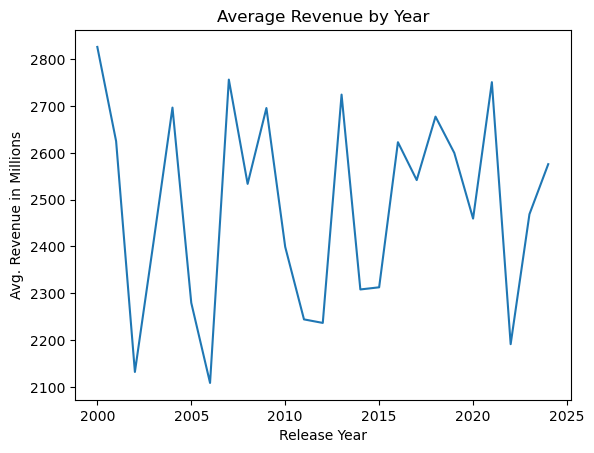

In [37]:
rev.plot(ylabel="Avg. Revenue in Millions", kind="line", title="Average Revenue by Year")

To filter only for games with the Trending Status listed as declining

In [20]:
mask = data["Trending Status"] == "Declining"
declining = data[mask]
declining

,Game Title,Genre,Platform,Release Year,Developer,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score,Esports Popularity,Trending Status
2,Fantasy Rivals 1,Strategy,Xbox,2018,Microsoft,1278.29,160.09,48.40,51,Yes,Declining
3,Warzone Chronicles 5,Horror,Xbox,2002,Microsoft,361.26,98.14,32.96,91,No,Declining
6,Neon Speed 4,Strategy,Cross-Platform,2008,Sony,1415.65,110.52,30.57,78,No,Declining
7,Cyber Quest 3,Action,Mobile,2002,Ubisoft,1473.01,57.48,15.39,82,No,Declining
10,Warzone Chronicles 3,Racing,Xbox,2007,Activision,4494.00,13.07,6.35,74,No,Declining
...,...,...,...,...,...,...,...,...,...,...,...
982,Galaxy Raiders 2,Adventure,Mobile,2013,Ubisoft,711.86,106.65,16.52,88,No,Declining
994,Battle Warriors 1,Horror,Nintendo Switch,2017,EA,2550.05,169.15,68.20,75,Yes,Declining
996,Battle Warriors 4,Simulation,PlayStation,2016,Capcom,367.94,152.19,28.36,68,Yes,Declining
998,Galaxy Raiders 4,Sports,Mobile,2015,Ubisoft,2737.73,31.27,13.03,61,Yes,Declining


To determine the breakdown of genres that the games designated as declining fall within:
(mul multiplies the output of value_counts by 100 to get a percentage)

In [22]:
declining["Genre"].value_counts(normalize=True).mul(100).round(1)

Genre
Strategy      14.1
Action        10.7
Fighting      10.1
Simulation    10.1
Shooter        9.8
Adventure      9.8
Racing         9.2
Sports         9.2
RPG            8.9
Horror         8.0
Name: proportion, dtype: float64

<Axes: title={'center': 'Declining Games by Genre'}, xlabel='Genre', ylabel='Share out of 100%'>

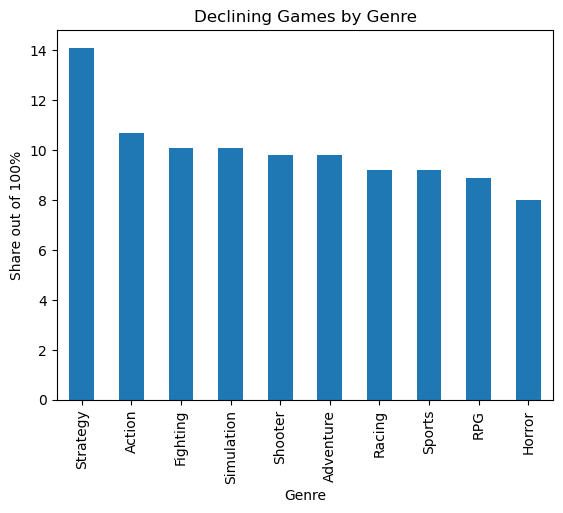

In [46]:
declining["Genre"].value_counts(normalize=True).mul(100).round(1).plot(kind="bar",
                                    ylabel="Share out of 100%",
                                    title="Declining Games by Genre")

In [27]:
mask2 = data["Trending Status"] == "Rising"
Rising = data[mask2]
Rising

,Game Title,Genre,Platform,Release Year,Developer,Revenue (Millions $),Players (Millions),Peak Concurrent Players,Metacritic Score,Esports Popularity,Trending Status
8,Warzone Chronicles 1,Adventure,Xbox,2003,Activision,752.25,192.70,71.06,92,Yes,Rising
9,Neon Speed 5,Sports,Mobile,2013,EA,4131.18,126.90,24.95,61,Yes,Rising
11,Cyber Quest 4,RPG,Nintendo Switch,2003,Rockstar,2825.97,66.72,27.69,70,No,Rising
13,Cyber Quest 1,Fighting,Mobile,2008,Activision,2370.04,116.71,53.21,66,No,Rising
15,Legends of Valor 2,Horror,Nintendo Switch,2003,Bandai Namco,3785.82,109.04,23.82,73,Yes,Rising
...,...,...,...,...,...,...,...,...,...,...,...
986,Warzone Chronicles 3,Adventure,Xbox,2018,Sony,1441.53,150.33,20.68,57,No,Rising
987,Cyber Quest 1,Action,Cross-Platform,2010,Rockstar,570.14,170.06,41.50,85,No,Rising
993,Zombie Outbreak 3,Strategy,Mobile,2020,Sony,1951.64,129.91,45.43,74,No,Rising
995,Battle Warriors 1,Shooter,Cross-Platform,2006,Rockstar,1262.82,79.69,15.90,99,No,Rising


In [28]:
Rising["Genre"].value_counts(normalize=True).mul(100).round(1)

Genre
Action        13.7
Fighting      12.2
Sports        11.9
Strategy      10.1
Shooter       10.1
Racing         9.9
Horror         9.6
Adventure      8.7
Simulation     7.2
RPG            6.6
Name: proportion, dtype: float64

<Axes: title={'center': 'Rising Games by Genre'}, xlabel='Genre', ylabel='Share out of 100%'>

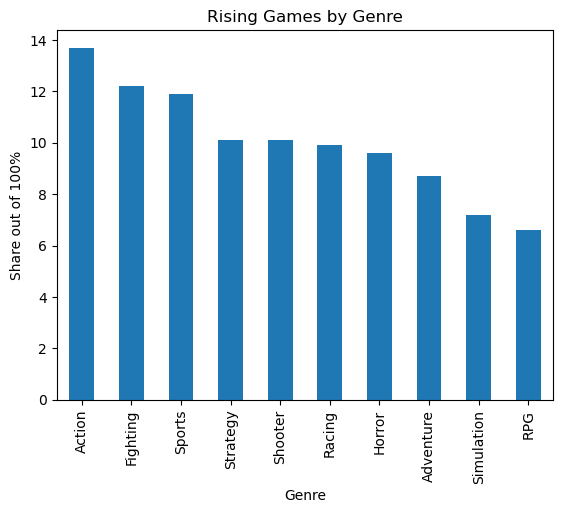

In [47]:
Rising["Genre"].value_counts(normalize=True).mul(100).round(1).plot(kind="bar",
                            ylabel="Share out of 100%",
                            title="Rising Games by Genre")

In the previous visualizations, the genre that most declining games fell under was strategy. However, action comprises the top genre for rising games and the second largest share of declining games, suggesting that this is a popular genre generally for video game creators. 

<Axes: title={'center': "Trending Games' Revenue Generation by Genre"}, xlabel='Genre', ylabel='Revenue in Millions'>

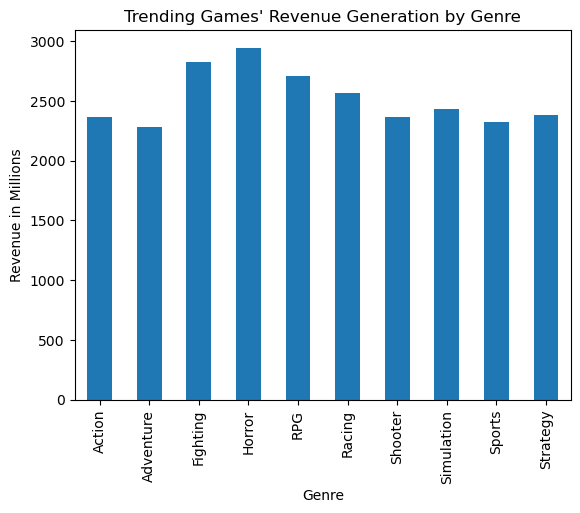

In [58]:
#mask2 = data["Trending Status"] == "Rising"
#Rising = data[mask2]

(Rising.groupby("Genre")["Revenue (Millions $)"].mean().
                plot(kind="bar",
                title = "Trending Games' Revenue Generation by Genre",
                ylabel = "Revenue in Millions",)
)

<Axes: title={'center': "Declining Games' Revenue Generation by Genre"}, xlabel='Genre', ylabel='Revenue in Millions'>

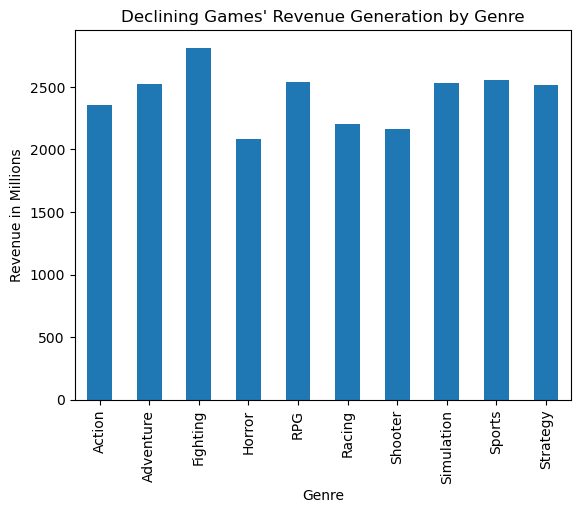

In [61]:
#mask = data["Trending Status"] == "Declining"
#declining = data[mask]

declining.groupby("Genre")["Revenue (Millions $)"].mean().plot(kind="bar",
                title = "Declining Games' Revenue Generation by Genre",
                ylabel = "Revenue in Millions")
